In [2]:
import pandas as pd 

# loading data

In [3]:

# إنشاء البيانات
data = {
    "Game" :["1st","2end","3rd","4rd"],
    "Date": ["2025-02-27", "2025-03-29", "2025-04-07", "2025-04-12"],
    "Opponent": ["Al Wahda", "Dibba Al Hisn", "Shabab Al Ahli", "Al Orooba"],
    "Minutes Played": [77, 90, 90, 61],
    "Shoots": [0, 6, 1, 1],
    "Goals": [0, 1, 0, 0],
    "Assists": [0, 0, 0, 0],
    "Pitch": ["Away", "Away", "Away", "Home"],
    "Result": ["L", "L", "D", "W"]
}

# تحويل البيانات إلى DataFrame
df = pd.DataFrame(data)

# حفظ البيانات في ملف CSV
df.to_csv("rahimi_last4_matches.csv", index=False)

# عرض البيانات
df

,Game,Date,Opponent,Minutes Played,Shoots,Goals,Assists,Pitch,Result
0,1st,2025-02-27,Al Wahda,77,0,0,0,Away,L
1,2end,2025-03-29,Dibba Al Hisn,90,6,1,0,Away,L
2,3rd,2025-04-07,Shabab Al Ahli,90,1,0,0,Away,D
3,4rd,2025-04-12,Al Orooba,61,1,0,0,Home,W


In [4]:
# تحميل البيانات من ملف CSV
df = pd.read_csv("rahimi_last4_matches.csv")

# عرض أول خمس صفوف من البيانات
df.head()


,Game,Date,Opponent,Minutes Played,Shoots,Goals,Assists,Pitch,Result
0,1st,2025-02-27,Al Wahda,77,0,0,0,Away,L
1,2end,2025-03-29,Dibba Al Hisn,90,6,1,0,Away,L
2,3rd,2025-04-07,Shabab Al Ahli,90,1,0,0,Away,D
3,4rd,2025-04-12,Al Orooba,61,1,0,0,Home,W


# Exploratory data analysis EDI
استكشاف 

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("rahimi_last4_matches.csv")
df

,Game,Date,Opponent,Minutes Played,Shoots,Goals,Assists,Pitch,Result
0,1st,2025-02-27,Al Wahda,77,0,0,0,Away,L
1,2end,2025-03-29,Dibba Al Hisn,90,6,1,0,Away,L
2,3rd,2025-04-07,Shabab Al Ahli,90,1,0,0,Away,D
3,4rd,2025-04-12,Al Orooba,61,1,0,0,Home,W


In [7]:
df.describe()


,Minutes Played,Shoots,Goals,Assists
count,4.000000,4.000000,4.00,4.0
mean,79.500000,2.000000,0.25,0.0
std,13.771952,2.708013,0.50,0.0
min,61.000000,0.000000,0.00,0.0
25%,73.000000,0.750000,0.00,0.0
50%,83.500000,1.000000,0.00,0.0
75%,90.000000,2.250000,0.25,0.0
max,90.000000,6.000000,1.00,0.0


In [8]:
# عدد الأهداف و التسديدات
total_goals = df['Goals'].sum()
total_shoots = df['Shoots'].sum()
print(f"Total Goals: {total_goals}, Total Shoots: {total_shoots}")


Total Goals: 1, Total Shoots: 8


In [9]:
# معدل الأهداف لكل تسديدة
if total_shoots > 0:
    goal_conversion_rate = (total_goals / total_shoots) * 100
    print(f"Goal Conversion Rate: {goal_conversion_rate:.2f}%")
else:
    print("No shoots recorded.")


Goal Conversion Rate: 12.50%


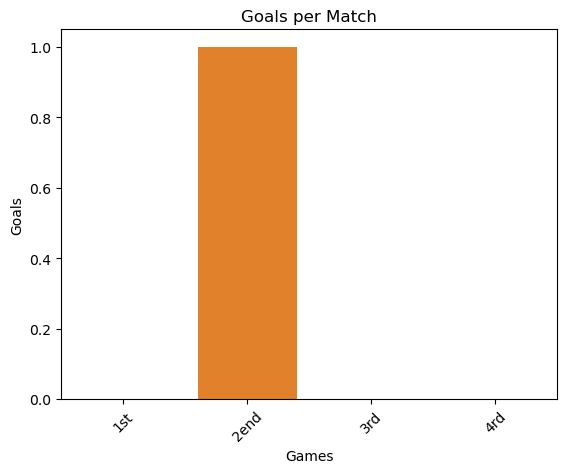

In [19]:
# عدد الأهداف في كل مبارة
sns.barplot(x='Game', y='Goals', data=df)
plt.title('Goals per Match')
plt.xlabel('Games')
plt.ylabel('Goals')
plt.xticks(rotation=45)
plt.show()


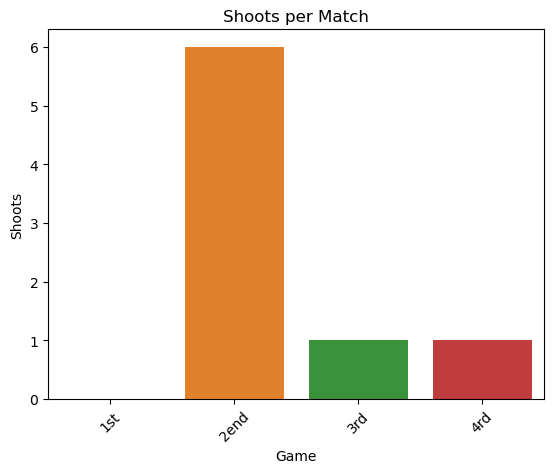

In [10]:
# عدد التسديدات في كل مبارة 
sns.barplot(x='Game', y='Shoots', data=df)
plt.title('Shoots per Match')
plt.xlabel('Game')
plt.ylabel('Shoots')
plt.xticks(rotation=45)
plt.show()


# Build a Predictive Model for Player Performance

In [11]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error


In [12]:
df = pd.read_csv("rahimi_last4_matches.csv")
df

,Game,Date,Opponent,Minutes Played,Shoots,Goals,Assists,Pitch,Result
0,1st,2025-02-27,Al Wahda,77,0,0,0,Away,L
1,2end,2025-03-29,Dibba Al Hisn,90,6,1,0,Away,L
2,3rd,2025-04-07,Shabab Al Ahli,90,1,0,0,Away,D
3,4rd,2025-04-12,Al Orooba,61,1,0,0,Home,W


In [13]:
# تحويل عمود 'Pitch' إلى قيم رقمية
df['Pitch'] = df['Pitch'].map({'Home': 1, 'Away': 0})

# تحويل عمود 'Result' إلى قيم رقمية
result_mapping = {'W': 3, 'D': 1, 'L': 0}
df['Result'] = df['Result'].map(result_mapping)


In [14]:
# تحويل عمود 'Date' إلى نوع datetime
df['Date'] = pd.to_datetime(df['Date'])

# حساب عدد الأيام منذ أول مباراة
df['Days_Since_First_Match'] = (df['Date'] - df['Date'].min()).dt.days


In [15]:
# الميزات
X = df[['Minutes Played', 'Shoots', 'Assists', 'Pitch', 'Result', 'Days_Since_First_Match']]

# المتغير الهدف
y = df['Goals']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [17]:
# إنشاء النموذج
model = LinearRegression()

# تدريب النموذج
model.fit(X_train, y_train)


LinearRegression()

In [18]:
# التنبؤ على مجموعة الاختبار
y_pred = model.predict(X_test)

# حساب متوسط الخطأ التربيعي
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")


Mean Squared Error: 1.0


# Predict Player Performance in the Next match 

In [21]:
import numpy as np

# بيانات المباراة القادمة

new_match = np.array([[90, 3, 1, 0, 1, 54]]) 
# [Minutes Played, Shoots, Assists, Pitch, Result, Days Since First Match]
new_match

array([[90,  3,  1,  0,  1, 54]])

In [26]:
# Expected goals in the next match 

In [23]:
#  استخدام نمودج للتنبؤ
predicted_goals = model.predict(new_match)
print(f"Exp Goal in Next Match: {predicted_goals[0]:.2f}")


Exp Goal in Next Match: 0.00


/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Create an Interactive Interface with ipywidgets

In [62]:
 # إنشاء واجهة تفاعلية

In [49]:
import joblib
import pandas as pd
import ipywidgets as widgets
from IPython.display import display


In [50]:
# تحميل النموذج المحفوظ
model = joblib.load('best_model.pkl')


In [54]:
# Input widgets
minutes_played = widgets.IntSlider(value=90, min=0, max=120, step=1, description='Minutes Played:')
shots = widgets.IntSlider(value=2, min=0, max=10, step=1, description='Shots:')
home_away = widgets.ToggleButtons(options=[('Home', 1), ('Away', 0)], description='Match Location:')
opponent_strength = widgets.FloatSlider(value=0.5, min=0.0, max=1.0, step=0.1, description='Opponent Strength:')


In [59]:
# زر التنبؤ
predict_button = widgets.Button(description='expect')

# دالة التنبؤ
def predict_goal(b):
    # إعداد بيانات الإدخال
    input_data = pd.DataFrame({
        'minutes_played': [minutes_played.value],
        'shots': [shots.value],
        'home_away': [home_away.value],
        'opponent_strength': [opponent_strength.value]
    })
    
    # التنبؤ
    predicted_goals = model.predict(input_data)
    
    # عرض النتيجة
    print(f"عدد الأهداف المتوقع لسفيان رحيمي في المباراة القادمة: {predicted_goals[0]:.2f}")

# ربط الزر بالدالة
predict_button.on_click(predict_goal)


In [60]:
# عرض عناصر الإدخال والزر
display(minutes_played, shots, home_away, opponent_strength, predict_button)


IntSlider(value=92, description='Minutes Played:', max=120)

IntSlider(value=5, description='Shots:', max=10)

ToggleButtons(description='Match Location:', index=1, options=(('Home', 1), ('Away', 0)), value=0)

FloatSlider(value=0.7, description='Opponent Strength:', max=1.0)

Button(description='expect', style=ButtonStyle())